# Task 2: Generative Models

In this task, I implemented two generative models on the Fashion-MNIST dataset:

1. **Variational Autoencoder (VAE)**
2. **Generative Adversarial Network (GAN)**

I used Fashion-MNIST which contains grayscale images of clothing items and is well-suited for generative modeling experiments.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Using device: cuda
Train size: 60000
Test size: 10000


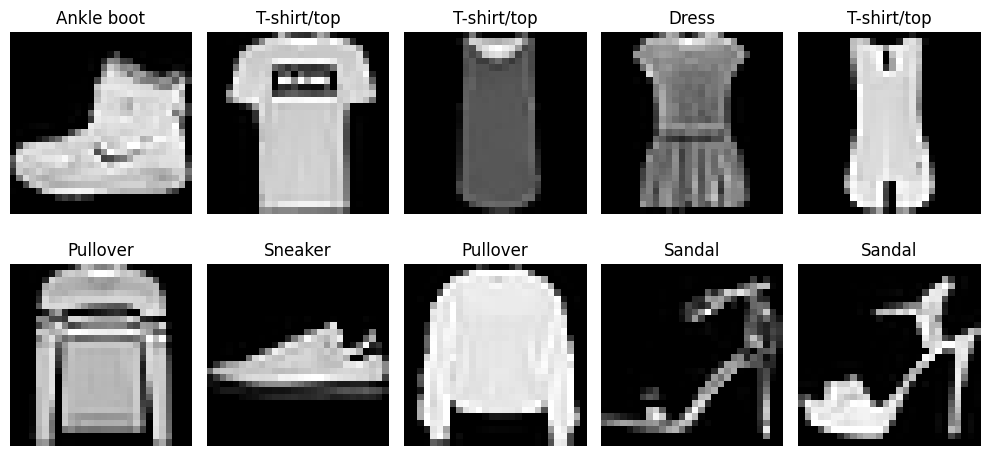

In [2]:
classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Part 1: Variational Autoencoder (VAE)

A Variational Autoencoder is a generative model that learns a compressed latent representation of the input data and then reconstructs the input from that latent space. Unlike a standard autoencoder, a VAE learns a probability distribution in the latent space, which allows new images to be generated by sampling from that distribution.

In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

In [4]:
def vae_loss(recon_x, x, mu, logvar):
    x = x.view(-1, 784)
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + kld

In [5]:
vae = VAE().to(device)
optimizer_vae = optim.Adam(vae.parameters(), lr=1e-3)

print(vae)

VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=784, bias=True)
)


In [6]:
def train_vae(model, train_loader, optimizer, device, epochs=10):
    model.train()
    losses = []

    for epoch in range(epochs):
        train_loss = 0

        for images, _ in train_loader:
            images = images.to(device)
            images = images.view(-1, 784)

            optimizer.zero_grad()
            recon_batch, mu, logvar = model(images)
            loss = vae_loss(recon_batch, images, mu, logvar)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_loss = train_loss / len(train_loader.dataset)
        losses.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}")

    return losses

In [7]:
vae_losses = train_vae(vae, train_loader, optimizer_vae, device, epochs=10)

Epoch [1/10], Average Loss: 285.1842
Epoch [2/10], Average Loss: 256.2420
Epoch [3/10], Average Loss: 250.5275
Epoch [4/10], Average Loss: 247.7330
Epoch [5/10], Average Loss: 246.1229
Epoch [6/10], Average Loss: 244.9910
Epoch [7/10], Average Loss: 244.1803
Epoch [8/10], Average Loss: 243.5834
Epoch [9/10], Average Loss: 243.0414
Epoch [10/10], Average Loss: 242.6760


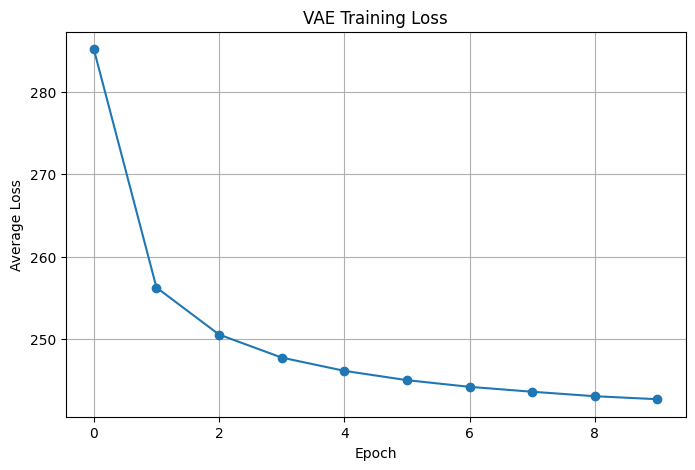

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(vae_losses, marker='o')
plt.title("VAE Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True)
plt.show()

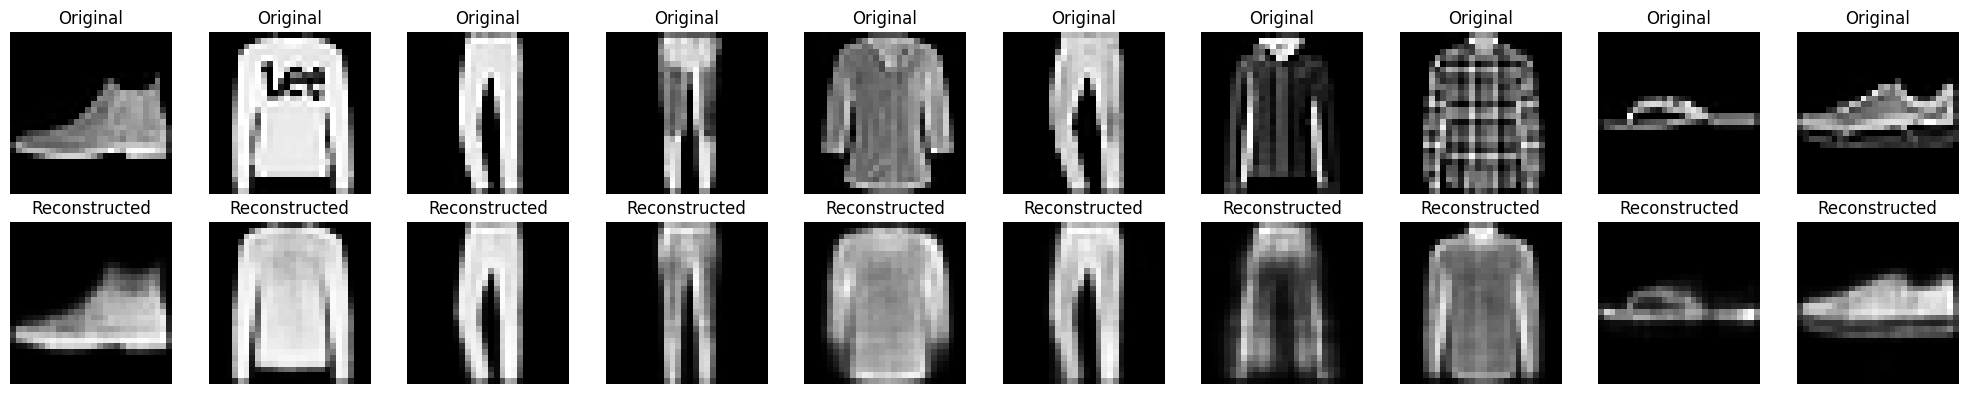

In [9]:
vae.eval()

with torch.no_grad():
    images, _ = next(iter(test_loader))
    images = images.to(device)
    flat_images = images.view(-1, 784)

    recon_images, _, _ = vae(flat_images)

    images = images.cpu().view(-1, 1, 28, 28)
    recon_images = recon_images.cpu().view(-1, 1, 28, 28)

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(recon_images[i].squeeze(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.tight_layout()
plt.show()

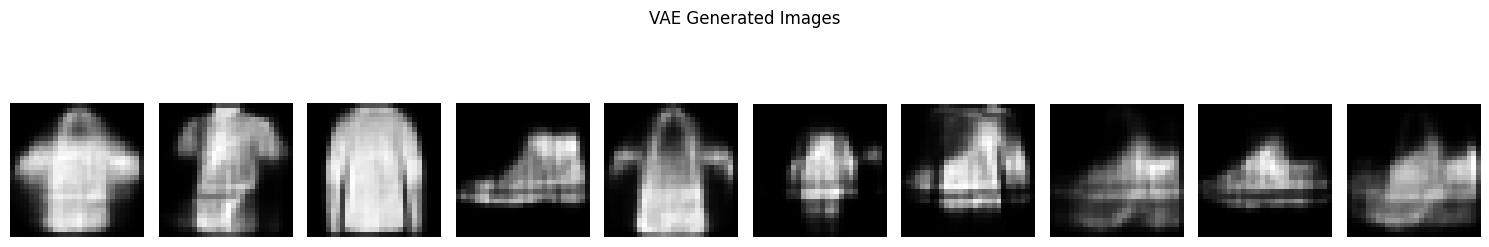

In [10]:
with torch.no_grad():
    z = torch.randn(10, 20).to(device)
    generated = vae.decode(z).cpu().view(-1, 1, 28, 28)

plt.figure(figsize=(15, 3))
for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(generated[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("VAE Generated Images")
plt.tight_layout()
plt.show()

## Part 1: VAE Results and Analysis

### Training Results
The VAE was trained for 10 epochs on the Fashion-MNIST dataset. The training loss decreased steadily from 285.18 to 242.68, indicating that the model successfully learned both to reconstruct images and to regularize the latent space.


### Reconstruction Quality

The reconstructed images preserve the overall structure and category of the original inputs:

- Shapes such as shoes, trousers, and shirts are clearly recognizable
- Fine details are somewhat blurred
- The model captures general patterns rather than sharp edges

This behavior is expected because VAEs balance reconstruction accuracy with latent space regularization.


### Generated Samples

The images generated by sampling from the latent space show:

- Clear clothing-like structures (e.g., shirts, shoes, dresses)
- Smooth but blurry appearances
- Variability across different samples

Although the images are not perfectly sharp, they demonstrate that the model has learned a meaningful representation of the data distribution.


### Observations

1. **Blurriness of Outputs**
   - Generated and reconstructed images appear smooth and slightly blurry

2. **Latent Space Learning**
   - The model successfully maps images into a continuous latent space

3. **Category Preservation**
   - Most reconstructed images retain their original class identity
   - This indicates effective encoding and decoding


### Conclusion

The Variational Autoencoder successfully learned a compressed latent representation of the Fashion-MNIST dataset. It was able to reconstruct input images and generate new samples that resemble real clothing items.

## Part 2: Generative Adversarial Network (GAN)

In this part, I implemented a Generative Adversarial Network to generate synthetic Fashion-MNIST images.

A GAN consists of two networks:
- **Generator**: generates fake images from random noise
- **Discriminator**: distinguishes between real and fake images

The two networks are trained in a minimax game:
- The generator tries to fool the discriminator
- The discriminator tries to correctly classify real vs fake images

In [11]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(-1, 1, 28, 28)

In [12]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img_flat = img.view(-1, 784)
        return self.model(img_flat)

In [13]:
latent_dim = 100

generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

criterion_gan = nn.BCELoss()

optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002)

print(generator)
print(discriminator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [14]:
def train_gan(generator, discriminator, train_loader, optimizer_G, optimizer_D, criterion, device, epochs=10):
    G_losses = []
    D_losses = []

    for epoch in range(epochs):
        g_loss_epoch = 0
        d_loss_epoch = 0

        for images, _ in train_loader:
            batch_size = images.size(0)
            images = images.to(device)

            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # --- Train Discriminator ---
            optimizer_D.zero_grad()

            outputs_real = discriminator(images)
            loss_real = criterion(outputs_real, real_labels)

            z = torch.randn(batch_size, latent_dim).to(device)
            fake_images = generator(z)

            outputs_fake = discriminator(fake_images.detach())
            loss_fake = criterion(outputs_fake, fake_labels)

            d_loss = loss_real + loss_fake
            d_loss.backward()
            optimizer_D.step()

            # --- Train Generator ---
            optimizer_G.zero_grad()

            outputs_fake = discriminator(fake_images)
            g_loss = criterion(outputs_fake, real_labels)

            g_loss.backward()
            optimizer_G.step()

            g_loss_epoch += g_loss.item()
            d_loss_epoch += d_loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss_epoch:.4f} | G Loss: {g_loss_epoch:.4f}")

        G_losses.append(g_loss_epoch)
        D_losses.append(d_loss_epoch)

    return G_losses, D_losses

In [15]:
G_losses, D_losses = train_gan(
    generator,
    discriminator,
    train_loader,
    optimizer_G,
    optimizer_D,
    criterion_gan,
    device,
    epochs=10
)

Epoch [1/10] | D Loss: 546.2992 | G Loss: 612.3679
Epoch [2/10] | D Loss: 480.5174 | G Loss: 1150.6193
Epoch [3/10] | D Loss: 598.7664 | G Loss: 616.6565
Epoch [4/10] | D Loss: 579.8080 | G Loss: 488.3201
Epoch [5/10] | D Loss: 538.4624 | G Loss: 604.9191
Epoch [6/10] | D Loss: 488.8025 | G Loss: 649.6077
Epoch [7/10] | D Loss: 588.1563 | G Loss: 569.1702
Epoch [8/10] | D Loss: 581.2665 | G Loss: 566.7362
Epoch [9/10] | D Loss: 575.3209 | G Loss: 674.4708
Epoch [10/10] | D Loss: 508.1463 | G Loss: 568.0596


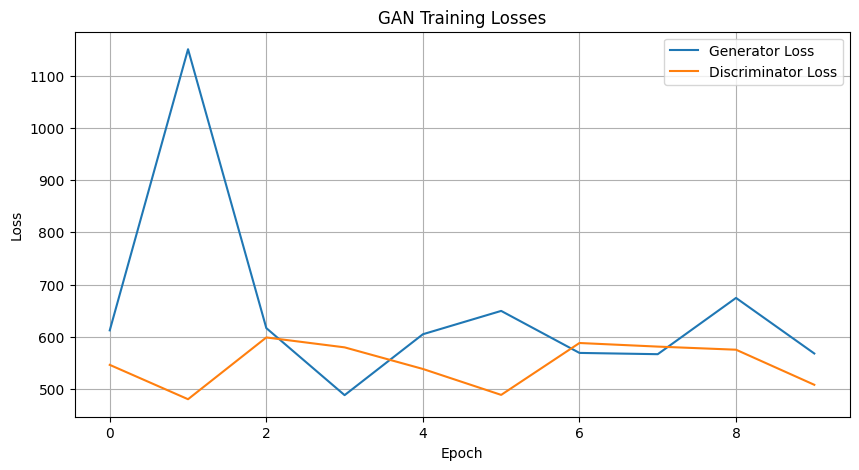

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.title("GAN Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

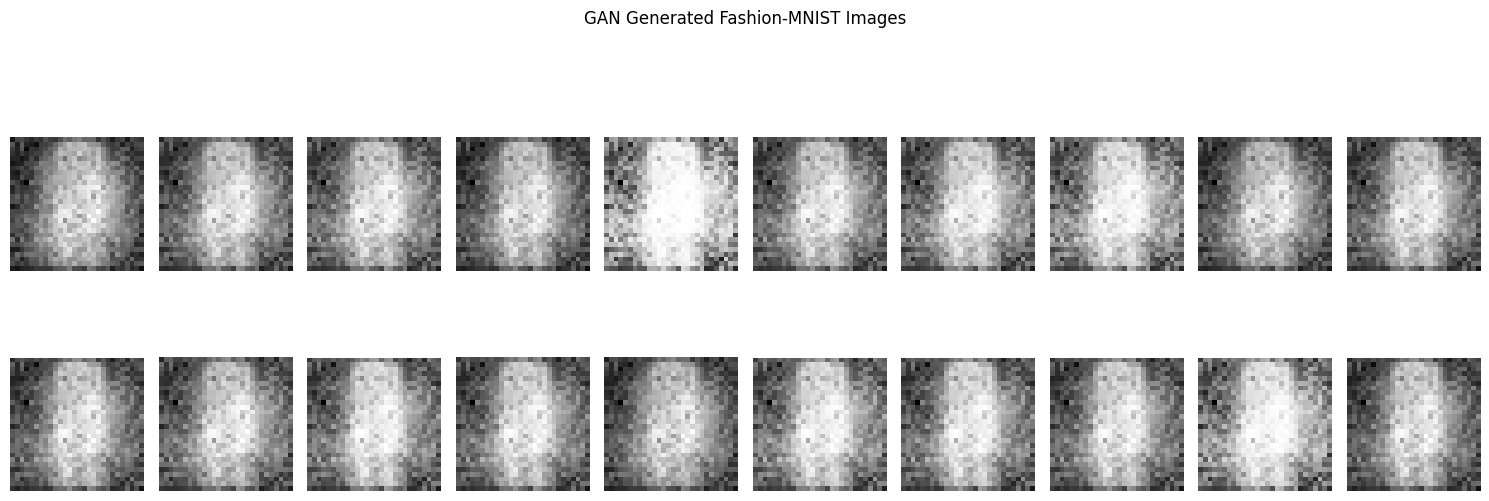

In [18]:
generator.eval()

with torch.no_grad():
    z = torch.randn(20, latent_dim).to(device)
    generated_images = generator(z).cpu()

# convert from [-1, 1] to [0, 1] for display
generated_images = (generated_images + 1) / 2

plt.figure(figsize=(15, 6))
for i in range(20):
    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(generated_images[i].squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("GAN Generated Fashion-MNIST Images")
plt.tight_layout()
plt.show()

## Part 2: GAN Results and Analysis

The GAN was trained for 10 epochs on the Fashion-MNIST dataset. Unlike the VAE, the GAN did not produce clearly recognizable clothing images. Instead, the generated samples appear noisy and lack distinct structure.

### Observations

- The generated images are blurry and highly similar to each other.
- There is little variation between samples, indicating mode collapse, where the generator produces limited outputs.
- The model failed to learn meaningful clothing representations.

### Reasons for Poor Performance

1. **Model Architecture**
   - A fully connected GAN was used instead of a convolutional GAN.
   - This limits the model’s ability to capture spatial features in images.

2. **Training Instability**
   - GANs are difficult to train and require careful balancing between generator and discriminator.
   - The fluctuating losses indicate unstable adversarial training.

3. **Insufficient Training Time**
   - More epochs may be required for meaningful image generation.


### Comparison with VAE

- The VAE produced recognizable (but blurry) clothing images.
- The GAN failed to produce structured outputs in this implementation.
- This highlights that GANs are more powerful but also significantly harder to train.

### Conclusion

Although the GAN did not produce high-quality images, the experiment demonstrates the challenges of adversarial training. With improved architectures such as DCGAN and longer training, GANs can outperform VAEs in image quality.